# TFT v2 Training — WTI News-Driven Liquidity

Ablation study for thesis §4.3.7/§4.3.8. Three variants, one notebook — toggle `ABLATION_VARIANT` in Cell 3.

| Variant | Target(s) | Max horizon | Categoricals | Entity flags |
|---------|-----------|-------------|--------------|:------------:|
| `v2.0` | `log_volume` | 1 h | int-encoded reals | ✗ |
| `v2.1` | `log_volume` | 1 h | proper categoricals | ✗ |
| `v2.2` | `log_volume`, `amihud`, `price_range` | 28 h | proper categoricals | ✓ (71) |

## Run sequence
1. Set `ABLATION_VARIANT = 'v2.0'` → run all cells end-to-end.
2. Change to `'v2.1'` → re-run from **Cell 3** (no kernel restart needed).
3. Same for `'v2.2'`.

Artifacts land in `04_outputs/tft_v2/{variant}/` after each run.

## Cell 2 — Imports and project root

In [1]:
import os, sys, json, re, pickle, sqlite3
from pathlib import Path

IS_COLAB = 'google.colab' in str(get_ipython())

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # Conditional install: probe first, install only if needed
    try:
        import lightning.pytorch as _pl_probe
        import pytorch_forecasting as _pf_probe
        del _pl_probe, _pf_probe
    except ImportError:
        !pip install -q "numpy<2.0"
        !pip install -q "torch>=2.3,<2.4" "torchvision>=0.18,<0.19" \
            "lightning>=2.2,<2.4" "pytorch-forecasting>=1.0,<1.2"
        print("\n" + "="*60)
        print("⚠️  PACKAGES INSTALLED — RESTART RUNTIME NOW")
        print("    Runtime → Restart runtime, then re-run this cell")
        print("="*60)
        import sys; sys.exit()

# All imports use lightning.pytorch namespace consistently
import numpy as np
import pandas as pd
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import QuantileLoss, MultiLoss
from pytorch_forecasting.data import GroupNormalizer
import warnings
warnings.filterwarnings('ignore')

# --- Path detection ---
if IS_COLAB:
    PROJECT_ROOT = Path('/content/drive/MyDrive/thesis/TFTv2')
    DB_PATH      = PROJECT_ROOT / 'wti_thesis.db'
    MODELS_DIR   = PROJECT_ROOT / 'models'
    OUTPUTS_DIR  = PROJECT_ROOT / 'tft_v2_outputs'
else:
    PROJECT_ROOT = Path('..').resolve()
    DB_PATH      = PROJECT_ROOT / '01_data' / 'wti_thesis.db'
    MODELS_DIR   = PROJECT_ROOT / '01_data' / 'models'
    OUTPUTS_DIR  = PROJECT_ROOT / '04_outputs' / 'tft_v2'

sys.path.insert(0, str(PROJECT_ROOT / '03_src'))

try:
    from tft.config import (TOTAL_HOURS, ENCODER_LENGTH, MAX_PREDICTION_LENGTH,
        TRAIN_END, VAL_START, VAL_END, TEST_START, TEST_END,
        WAR_ONSET_IDX, WAR_ONSET_DATETIME,
        verify_against_db,
        entity_to_column_name, ENTITY_COL_MAP, COL_TO_ENTITY)
    print(f"\n✓ Import successful")
    print(f"  TOTAL_HOURS = {TOTAL_HOURS}")
    print(f"  Split: train [0,{TRAIN_END}) val [{VAL_START},{VAL_END}) test [{TEST_START},{TEST_END})")
except ImportError as e:
    print(f"\n✗ Import failed: {e}")

pl.seed_everything(42, workers=True)
import torch
torch.use_deterministic_algorithms(True, warn_only=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'DB_PATH      : {DB_PATH}  (exists={DB_PATH.exists()})')
print(f'PyTorch      : {torch.__version__}')
print(f'GPU          : {torch.cuda.is_available()} | MPS: {torch.backends.mps.is_available()}')
print(f'Canonical entities: {len(ENTITY_COL_MAP)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42



✓ Import successful
  TOTAL_HOURS = 11232
  Split: train [0,6739) val [6787,9014) test [9062,11232)
PROJECT_ROOT : /content/drive/MyDrive/thesis/TFTv2
DB_PATH      : /content/drive/MyDrive/thesis/TFTv2/wti_thesis.db  (exists=True)
PyTorch      : 2.3.1+cu121
GPU          : True | MPS: False
Canonical entities: 71


In [2]:
# Verify dataset distribution
print("MAX_PREDICTION_LENGTH", MAX_PREDICTION_LENGTH)
print("TRAIN_END", TRAIN_END)
print("VAL_START", VAL_START)
print("VAL_END", VAL_END)
print("TEST_START", TEST_START)
print("TEST_END", TEST_END)


MAX_PREDICTION_LENGTH 12
TRAIN_END 6739
VAL_START 6787
VAL_END 9014
TEST_START 9062
TEST_END 11232


## Cell 3 — Ablation variant toggle and config

In [13]:
# ── TOGGLE THIS ──────────────────────────────────────────────────────────────
ABLATION_VARIANT = 'v2.2'   # 'v2.0' | 'v2.1' | 'v2.2'
# ─────────────────────────────────────────────────────────────────────────────

assert ABLATION_VARIANT in ('v2.0', 'v2.1', 'v2.2'), f'Unknown variant: {ABLATION_VARIANT}'

verify_against_db(str(DB_PATH))

VARIANT_CONFIGS = {
    'v2.0': {
        'targets':               ['log_volume'],
        'max_prediction_length': 1,
        'proper_categoricals':   False,
        'entity_flags':          False,
    },
    'v2.1': {
        'targets':               ['log_volume'],
        'max_prediction_length': 1,
        'proper_categoricals':   True,
        'entity_flags':          False,
    },
    'v2.2': {
        'targets':               ['log_volume', 'amihud', 'price_range'],
        'max_prediction_length': MAX_PREDICTION_LENGTH,  # 28
        'proper_categoricals':   True,
        'entity_flags':          True,
    },
}
cfg = VARIANT_CONFIGS[ABLATION_VARIANT]

# Evaluation horizons for v2.2 multi-horizon metrics (0-indexed)
EVAL_HORIZON_INDICES = [0, 2, 5, 11]   # → 1h, 3h, 6h, 12h, 28h
EVAL_HORIZON_LABELS  = [1, 3, 6, 12]

VARIANT_OUT_DIR = OUTPUTS_DIR / ABLATION_VARIANT
(VARIANT_OUT_DIR / 'logs').mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Variant              : {ABLATION_VARIANT}')
print(f'  targets            : {cfg["targets"]}')
print(f'  max_pred_length    : {cfg["max_prediction_length"]}')
print(f'  proper_categoricals: {cfg["proper_categoricals"]}')
print(f'  entity_flags       : {cfg["entity_flags"]}')
print(f'Output dir           : {VARIANT_OUT_DIR}')

Variant              : v2.2
  targets            : ['log_volume', 'amihud', 'price_range']
  max_pred_length    : 12
  proper_categoricals: True
  entity_flags       : True
Output dir           : /content/drive/MyDrive/thesis/TFTv2/tft_v2_outputs/v2.2


## Cell 4 — Load and aggregate modeling data

Builds one row per trading hour:
- Continuous LLM features: mean across usable articles in that hour
- Dominant categoricals: event_type[0] and time_horizon from the highest-magnitude article
- Entity flags (v2.2): binary MAX across articles
- No-news hours: continuous → 0.0, categoricals → `'no_news'`, flags → 0

In [4]:
# entity_to_column_name, ENTITY_COL_MAP, COL_TO_ENTITY imported from tft.config
ENT_COLUMNS = list(ENTITY_COL_MAP.values())
ENT_MAP     = ENTITY_COL_MAP

conn = sqlite3.connect(DB_PATH)

# Market context backbone (all 11,232 trading hours)
df_mc = pd.read_sql(
    'SELECT datetime_hour, log_volume, price_range, log_return, amihud, dxy, vix '
    'FROM market_context ORDER BY datetime_hour',
    conn
)
df_mc['datetime_hour'] = pd.to_datetime(df_mc['datetime_hour'], utc=True)
assert len(df_mc) == TOTAL_HOURS, f'Expected {TOTAL_HOURS} hours, got {len(df_mc)}'

# Usable article LLM features (one row per article)
df_arts = pd.read_sql("""
    SELECT l.article_id, l.datetime_hour,
           l.sentiment_score, l.magnitude, l.certainty,
           l.supply_impact, l.demand_impact, l.risk_premium,
           l.event_type, l.time_horizon
           FROM liquidity l JOIN llm_features f ON l.article_id = f.article_id
           WHERE f.usable_strict = 1
""", conn)
df_arts['datetime_hour'] = pd.to_datetime(df_arts['datetime_hour'], utc=True)

# Entity mention rows (only for usable articles via article_entities)
df_ent = pd.read_sql(
    'SELECT article_id, canonical_entity FROM article_entities',
    conn
)

conn.close()

# Parse event_type JSON array → primary category
def parse_event_type(val):
    if not val:
        return 'other'
    try:
        arr = json.loads(val)
        return arr[0] if arr else 'other'
    except (json.JSONDecodeError, TypeError):
        return str(val)

df_arts['event_type_primary'] = df_arts['event_type'].apply(parse_event_type)

# --- Hourly aggregation ---

# Dominant article per hour = highest magnitude, with article_id as deterministic tie-breaker
df_arts_sorted = df_arts.sort_values(
    ['datetime_hour', 'magnitude', 'article_id'],
    ascending=[True, False, True]  # earliest hour, highest magnitude, lowest article_id wins on tie
)
df_dom = df_arts_sorted.groupby('datetime_hour').first()[['event_type_primary', 'time_horizon']]

# Create directional sentiment columns for the aggregation
df_arts['bearish_sentiment'] = df_arts['sentiment_score'].where(
    df_arts['sentiment_score'] < -0.1, 0.0
)
df_arts['bullish_sentiment'] = df_arts['sentiment_score'].where(
    df_arts['sentiment_score'] > 0.1, 0.0
)

df_hourly_llm = (
    df_arts
    .groupby('datetime_hour')
    .agg(
        n_articles        = ('article_id',        'count'),
        sentiment_score   = ('sentiment_score',   'mean'),
        bearish_sentiment = ('bearish_sentiment', 'mean'),
        bullish_sentiment = ('bullish_sentiment', 'mean'),
        supply_impact     = ('supply_impact',     'mean'),
        demand_impact     = ('demand_impact',     'mean'),
        risk_premium      = ('risk_premium',      'mean'),
        magnitude         = ('magnitude',         'mean'),
        certainty         = ('certainty',         'mean'),
    )
    .join(df_dom)
    .reset_index()
)

# --- Entity flag matrix: datetime_hour × entity_col ---
df_ent['ent_col'] = df_ent['canonical_entity'].map(ENT_MAP)
df_ent_valid = df_ent.dropna(subset=['ent_col'])

df_ent_valid = df_ent_valid.merge(
    df_arts[['article_id', 'datetime_hour']].drop_duplicates('article_id'),
    on='article_id', how='left'
)
df_ent_valid = df_ent_valid.dropna(subset=['datetime_hour'])

df_ent_flags = (
    df_ent_valid
    .groupby(['datetime_hour', 'ent_col'])
    .size()
    .unstack(fill_value=0)
    .clip(upper=1)
    .reset_index()
)
df_ent_flags.columns.name = None
for col in ENT_COLUMNS:
    if col not in df_ent_flags.columns:
        df_ent_flags[col] = 0
df_ent_flags = df_ent_flags[['datetime_hour'] + ENT_COLUMNS]

# --- Build final per-hour DataFrame ---
df = df_mc.copy()
df = df.merge(df_hourly_llm, on='datetime_hour', how='left')
df = df.merge(df_ent_flags,  on='datetime_hour', how='left')

# Fill no-news hours
CONT_LLM = ['sentiment_score', 'bearish_sentiment', 'bullish_sentiment',
             'supply_impact', 'demand_impact', 'risk_premium',
             'magnitude', 'certainty']
df[CONT_LLM]  = df[CONT_LLM].fillna(0.0)
df['n_articles']         = df['n_articles'].fillna(0).astype(float)
df['event_type_primary'] = df['event_type_primary'].fillna('no_news')
df['time_horizon']       = df['time_horizon'].fillna('no_news')
for col in ENT_COLUMNS:
    df[col] = df[col].fillna(0).astype(float)

# Calendar features
df['hour']         = df['datetime_hour'].dt.hour.astype(float)
df['day_of_week']  = df['datetime_hour'].dt.dayofweek.astype(float)
df['month']        = df['datetime_hour'].dt.month.astype(float)
df['is_us_session']= ((df['datetime_hour'].dt.hour >= 13) &
                      (df['datetime_hour'].dt.hour <= 21)).astype(float)
df['is_wednesday'] = (df['datetime_hour'].dt.dayofweek == 2).astype(float)

# pytorch-forecasting required columns
df = df.sort_values('datetime_hour').reset_index(drop=True)
df['time_idx'] = df.index
df['asset']    = 'WTI'

# Int-encoded fallback columns for v2.0
EVENT_TYPE_INT = {'no_news':0,'geopolitical':1,'supply':2,'demand':3,'macro':4,'technical':5,'other':6}
TIME_HORIZON_INT = {'no_news':0,'immediate':1,'short_term':2,'structural':3,'long_term':3}
df['event_type_int']   = df['event_type_primary'].map(EVENT_TYPE_INT).fillna(6).astype(float)
df['time_horizon_int'] = df['time_horizon'].map(TIME_HORIZON_INT).fillna(0).astype(float)


# --- Verify dominant-article selection (5 sample hours with >1 article) ---
_multi = df_arts.groupby('datetime_hour').filter(lambda g: len(g) > 1)
if len(_multi) > 0:
    _sample_hours = _multi['datetime_hour'].drop_duplicates().iloc[:5]
    print('\nDominant-article verification (hour → chosen article vs candidates):')
    for _h in _sample_hours:
        _grp = df_arts[df_arts['datetime_hour'] == _h][[
             'magnitude', 'article_id', 'event_type_primary', 'time_horizon'
        ]].sort_values('magnitude', ascending=False)
        _chosen = _grp.iloc[0]
        print(f'  {_h}')
        print(f'    CHOSEN  id={int(_chosen.article_id):>6}  mag={_chosen.magnitude:.2f}  '
              f'et={_chosen.event_type_primary}  th={_chosen.time_horizon}')
        for _, _r in _grp.iloc[1:].iterrows():
            print(f'    other   id={int(_r.article_id):>6}  mag={_r.magnitude:.2f}  '
                  f'et={_r.event_type_primary}  th={_r.time_horizon}')
else:
    print('No multi-article hours found in sample — skipping verification')

# Forward-fill sparse macro covariates (≤10 nulls in DXY/VIX due to yfinance gaps
# on holidays/half-sessions where WTI futures traded but the underlying index didn't update)
n_dxy_null = df['dxy'].isna().sum()
n_vix_null = df['vix'].isna().sum()
df['dxy'] = df['dxy'].ffill().bfill()  # ffill primary; bfill handles any null at row 0
df['vix'] = df['vix'].ffill().bfill()

# Returns can't be computed on the first hour (no prior price); fill the boundary NaN with 0
n_logret_null = df['log_return'].isna().sum()
df['log_return'] = df['log_return'].fillna(0.0)
df['amihud'] = df['amihud'].fillna(0.0)

print(f'Macro covariates forward-filled: {n_dxy_null} DXY, {n_vix_null} VIX nulls patched')


# Sanity
assert len(df) == TOTAL_HOURS
assert df[['log_volume','dxy','vix','log_return','amihud']].isna().sum().sum() == 0, (
    f'Unexpected nulls after fill: '
    f'log_volume={df["log_volume"].isna().sum()}, '
    f'dxy={df["dxy"].isna().sum()}, '
    f'vix={df["vix"].isna().sum()}, '
    f'log_return={df["log_return"].isna().sum()}'
)

print(f'Hourly DataFrame : {len(df):,} rows × {len(df.columns)} columns')
print(f'Hours with news  : {(df["n_articles"] > 0).sum():,} / {len(df):,}')
print(f'event_type_primary distribution:')
print(df['event_type_primary'].value_counts().to_string())


Dominant-article verification (hour → chosen article vs candidates):
  2024-05-13 12:00:00+00:00
    CHOSEN  id=  3005  mag=0.90  et=geopolitical  th=immediate
    other   id=   154  mag=0.90  et=geopolitical  th=structural
    other   id=  2724  mag=0.85  et=supply  th=short_term
    other   id=  2932  mag=0.85  et=geopolitical  th=immediate
    other   id=   267  mag=0.85  et=geopolitical  th=structural
    other   id=  2469  mag=0.85  et=supply  th=short_term
    other   id=  3007  mag=0.85  et=geopolitical  th=immediate
    other   id=  3053  mag=0.85  et=geopolitical  th=short_term
    other   id=  2911  mag=0.80  et=geopolitical  th=immediate
    other   id=  2069  mag=0.80  et=geopolitical  th=short_term
    other   id=  2663  mag=0.80  et=geopolitical  th=immediate
    other   id=    71  mag=0.80  et=geopolitical  th=immediate
    other   id=  1022  mag=0.80  et=supply  th=structural
    other   id=  2712  mag=0.80  et=geopolitical  th=short_term
    other   id=  2146  mag=0.8

In [14]:
print('bearish_sentiment' in df.columns)
print('bullish_sentiment' in df.columns)
print('sentiment_score' in df.columns)

# Verify directional features are correctly computed
_sample_bearish = df[df['bearish_sentiment'] < -0.05].head(3)
_sample_bullish = df[df['bullish_sentiment'] > 0.05].head(3)

print(f'\nDirectional features verification:')
print(f'  Rows with bearish_sentiment < -0.05: {(df["bearish_sentiment"] < -0.05).sum():,}')
print(f'  Rows with bullish_sentiment > 0.05:  {(df["bullish_sentiment"] > 0.05).sum():,}')
print(f'  Rows with both (contradictory hours): {((df["bearish_sentiment"] < -0.05) & (df["bullish_sentiment"] > 0.05)).sum():,}')

if len(_sample_bearish) > 0:
    print(f'\nSample bearish hours:')
    print(_sample_bearish[['datetime_hour', 'sentiment_score', 'bearish_sentiment', 'bullish_sentiment', 'n_articles']].to_string(index=False))

if len(_sample_bullish) > 0:
    print(f'\nSample bullish hours:')
    print(_sample_bullish[['datetime_hour', 'sentiment_score', 'bearish_sentiment', 'bullish_sentiment', 'n_articles']].to_string(index=False))

True
True
True

Directional features verification:
  Rows with bearish_sentiment < -0.05: 2,638
  Rows with bullish_sentiment > 0.05:  2,697
  Rows with both (contradictory hours): 1,015

Sample bearish hours:
            datetime_hour  sentiment_score  bearish_sentiment  bullish_sentiment  n_articles
2024-05-13 12:00:00+00:00         0.039681          -0.171884           0.210249      1444.0
2024-05-14 01:00:00+00:00        -0.700000          -0.700000           0.000000         1.0
2024-05-14 02:00:00+00:00         0.000000          -0.300000           0.300000         2.0

Sample bullish hours:
            datetime_hour  sentiment_score  bearish_sentiment  bullish_sentiment  n_articles
2024-05-13 12:00:00+00:00         0.039681          -0.171884           0.210249      1444.0
2024-05-13 13:00:00+00:00         0.600000           0.000000           0.600000         1.0
2024-05-13 18:00:00+00:00         0.100000           0.000000           0.150000         2.0


## Cell 5 — Train / val / test split

In [15]:
# Splits are locked in config — do not change
print(f'Total hours  : {TOTAL_HOURS:,}')
print(f'Train        : time_idx   0 – {TRAIN_END-1}  ({TRAIN_END:,} rows)')
print(f'[buffer]     : time_idx {TRAIN_END} – {VAL_START-1}  ({VAL_START-TRAIN_END} rows, encoder context)')
print(f'Val          : time_idx {VAL_START} – {VAL_END-1}  ({VAL_END-VAL_START:,} rows)')
print(f'[buffer]     : time_idx {VAL_END} – {TEST_START-1}  ({TEST_START-VAL_END} rows, encoder context)')
print(f'Test         : time_idx {TEST_START} – {TEST_END-1}  ({TEST_END-TEST_START:,} rows)')
print(f'  Pre-war    : time_idx {TEST_START} – {WAR_ONSET_IDX-1}  ({WAR_ONSET_IDX-TEST_START:,} rows)')
print(f'  War        : time_idx {WAR_ONSET_IDX} – {TEST_END-1}  ({TEST_END-WAR_ONSET_IDX:,} rows)')
print(f'  War onset  : {WAR_ONSET_DATETIME}')

Total hours  : 11,232
Train        : time_idx   0 – 6738  (6,739 rows)
[buffer]     : time_idx 6739 – 6786  (48 rows, encoder context)
Val          : time_idx 6787 – 9013  (2,227 rows)
[buffer]     : time_idx 9014 – 9061  (48 rows, encoder context)
Test         : time_idx 9062 – 11231  (2,170 rows)
  Pre-war    : time_idx 9062 – 10055  (994 rows)
  War        : time_idx 10056 – 11231  (1,176 rows)
  War onset  : 2026-03-01 23:00:00+00:00


## Cell 6 — Construct TimeSeriesDataSet objects

In [16]:
from pytorch_forecasting.data import GroupNormalizer, MultiNormalizer
# Shared kwargs for all variants
SHARED_KW = dict(
    time_idx             = 'time_idx',
    group_ids            = ['asset'],
    max_encoder_length   = ENCODER_LENGTH,
    allow_missing_timesteps = False,
    add_relative_time_idx   = True,
    add_target_scales       = True,
    add_encoder_length      = True,
    # REMOVED: static_categoricals = ['asset'],     # ← was forcing degenerate static context
    time_varying_known_reals = [
        'hour', 'day_of_week', 'month', 'is_us_session', 'is_wednesday'
    ],
)

# Variant-specific configuration
BASE_UNKNOWN_REALS = [
    'log_volume', 'price_range', 'log_return', 'amihud', 'dxy', 'vix',
    'sentiment_score',
    'supply_impact', 'demand_impact', 'risk_premium',
    'magnitude', 'certainty', 'n_articles',
]

if ABLATION_VARIANT == 'v2.0':
    VARIANT_KW = dict(
        target                          = 'log_volume',
        max_prediction_length           = 1,
        time_varying_unknown_reals      = BASE_UNKNOWN_REALS + ['event_type_int', 'time_horizon_int'],
        time_varying_unknown_categoricals = [],
        time_varying_known_categoricals = [],
        target_normalizer    = GroupNormalizer(groups=['asset']),   # ← match v1
    )
elif ABLATION_VARIANT == 'v2.1':
    VARIANT_KW = dict(
        target                          = 'log_volume',
        max_prediction_length           = 1,
        time_varying_unknown_reals      = BASE_UNKNOWN_REALS,
        # News categoricals are unknown: future hour's news is not available at
        # prediction time; decoder sees only encoder history + calendar features.
        time_varying_unknown_categoricals = ['event_type_primary', 'time_horizon'],
        time_varying_known_categoricals = [],
        target_normalizer    = GroupNormalizer(groups=['asset']),   # ← match v1
    )
else:  # v2.2
    VARIANT_KW = dict(
        target                          = ['log_volume', 'amihud', 'price_range'],
        max_prediction_length           = MAX_PREDICTION_LENGTH,
        time_varying_unknown_reals      = BASE_UNKNOWN_REALS + ENT_COLUMNS,
        # Same rationale: future news features unknown during the 28h decoder window.
        time_varying_unknown_categoricals = ['event_type_primary', 'time_horizon'],
        time_varying_known_categoricals = [],
        target_normalizer = MultiNormalizer([
        GroupNormalizer(groups=['asset']),
        GroupNormalizer(groups=['asset']),
        GroupNormalizer(groups=['asset']),
]),
    )

# Training dataset (rows 0 to TRAIN_END inclusive)
train_data = df[df['time_idx'] <= TRAIN_END].copy()
train_dataset = TimeSeriesDataSet(train_data, **SHARED_KW, **VARIANT_KW)

def make_eval_dataset(training_ds, df_full, min_pred_idx, max_pred_idx):
    """Create an eval dataset with encoder context starting before min_pred_idx
    and prediction targets ending at max_pred_idx."""
    context_start = max(0, min_pred_idx - ENCODER_LENGTH)
    return TimeSeriesDataSet.from_dataset(
        training_ds,
        df_full[(df_full['time_idx'] >= context_start) &
                (df_full['time_idx'] < max_pred_idx)].copy(),
        min_prediction_idx = min_pred_idx,
        predict            = False,
        stop_randomization = True,
    )

val_dataset  = make_eval_dataset(train_dataset, df, VAL_START, VAL_END)
test_dataset = make_eval_dataset(train_dataset, df, TEST_START, TEST_END)

print(f'Train samples : {len(train_dataset):,}')
print(f'Val samples   : {len(val_dataset):,}')
print(f'Test samples  : {len(test_dataset):,}')

Train samples : 6,681
Val samples   : 2,216
Test samples  : 2,159


## Cell 7 — Instantiate TemporalFusionTransformer

In [17]:
if isinstance(VARIANT_KW['target'], list):
    loss = MultiLoss([QuantileLoss()] * len(VARIANT_KW['target']))
else:
    loss = QuantileLoss()

tft = TemporalFusionTransformer.from_dataset(
    train_dataset,
    hidden_size               = 32,
    attention_head_size       = 4,
    dropout                   = 0.15,
    hidden_continuous_size    = 16,
    learning_rate             = 1e-3,
    loss                      = loss,
    reduce_on_plateau_patience= 3,
    log_interval              = -1,
    log_val_interval          = -1,
)

n_params = sum(p.numel() for p in tft.parameters() if p.requires_grad)
print(f'TFT {ABLATION_VARIANT}: {n_params:,} trainable parameters')
print(f'Loss: {loss.__class__.__name__}')

TFT v2.2: 298,329 trainable parameters
Loss: MultiLoss


In [18]:
print("\nModel parameter breakdown:")
for name, p in tft.named_parameters():
    if 'embed' in name.lower() or 'input' in name.lower():
        print(f"  {name}: shape {tuple(p.shape)}, params {p.numel()}")


Model parameter breakdown:
  input_embeddings.embeddings.event_type_primary.weight: shape (8, 5), params 40
  input_embeddings.embeddings.time_horizon.weight: shape (4, 3), params 12


## Cell 8 — Trainer setup

In [19]:
BATCH_SIZE = 128 if (torch.cuda.is_available() or torch.backends.mps.is_available()) else 64

train_loader = train_dataset.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
val_loader   = val_dataset.to_dataloader(  train=False, batch_size=BATCH_SIZE, num_workers=0)

callbacks = [
    EarlyStopping(
        monitor   = 'val_loss',
        patience  = 10,
        min_delta = 1e-4,
        mode      = 'min',
    ),
    ModelCheckpoint(
        monitor   = 'val_loss',
        save_top_k= 1,
        mode      = 'min',
        dirpath   = str(MODELS_DIR),
        filename  = f'tft_{ABLATION_VARIANT}-{{epoch}}-{{val_loss:.4f}}',
    ),
]

if torch.cuda.is_available():
    accelerator = 'gpu'
elif torch.backends.mps.is_available():
    accelerator = 'mps'
else:
    accelerator = 'cpu'

trainer = pl.Trainer(
    max_epochs       = 75,
    gradient_clip_val= 0.1,
    accelerator      = accelerator,
    devices          = 1,
    callbacks        = callbacks,
    logger           = CSVLogger(save_dir=str(VARIANT_OUT_DIR / 'logs'), name='', version=''),
    deterministic    = 'warn',
    enable_progress_bar = True,
)

print(f'Accelerator  : {accelerator}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Accelerator  : gpu
Batch size   : 128
Train batches: 52
Val batches  : 18


## Cell 9 — Train

Expected duration on Colab Pro A100: ~30 min for v2.0/v2.1, ~1.5–2 h for v2.2.

In [13]:
trainer.fit(tft, train_loader, val_loader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | MultiLoss                       | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 52     | train
3  | prescalers                         | ModuleDict                      | 3.2 K  | train
4  | static_variable_selection          | VariableSelectionNetwork        | 13.8 K | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 224 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 11.9 K | train
7  | static_context_variable_selectio

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## Cell 10 — Save best checkpoint path

In [12]:
best_path      = trainer.checkpoint_callback.best_model_path
best_val_loss  = float(trainer.checkpoint_callback.best_model_score)
best_epoch     = trainer.current_epoch

print(f'Best checkpoint : {best_path}')
print(f'Best val_loss   : {best_val_loss:.4f}')
print(f'Stopped at epoch: {best_epoch}')

TypeError: float() argument must be a string or a real number, not 'NoneType'

## Cell 11 — Load best checkpoint for evaluation

In [20]:
# Cell 11 — Load best checkpoint (works for fresh training OR after restart)
from pytorch_forecasting import TemporalFusionTransformer
import glob

def _val_loss_from_path(p):
    s = p.split('val_loss=')[1].replace('.ckpt', '')
    s = s.split('-')[0]  # strip Lightning dedup suffix like '-v1'
    return float(s)

# Try to get the checkpoint path from the live trainer first (fresh run)
try:
    best_path = trainer.checkpoint_callback.best_model_path
    best_val_loss = float(trainer.checkpoint_callback.best_model_score)
    best_epoch = trainer.current_epoch
    print("Using checkpoint from current training run")
except (NameError, TypeError, AttributeError):
    # Restart case: trainer not in memory OR exists but score is None
    ckpts = glob.glob(str(MODELS_DIR / f'tft_{ABLATION_VARIANT}-*.ckpt'))
    if not ckpts:
        raise FileNotFoundError(f"No checkpoint found for {ABLATION_VARIANT} in {MODELS_DIR}")
    best_path = min(ckpts, key=_val_loss_from_path)
    best_val_loss = _val_loss_from_path(best_path)
    best_epoch = int(best_path.split('epoch=')[1].split('-')[0])
    print("Loaded checkpoint from disk (post-restart)")

print(f'Best checkpoint : {best_path}')
print(f'Best val_loss   : {best_val_loss:.4f}')
print(f'Best epoch      : {best_epoch}')

tft_eval = TemporalFusionTransformer.load_from_checkpoint(best_path)
tft_eval.eval();

Loaded checkpoint from disk (post-restart)
Best checkpoint : /content/drive/MyDrive/thesis/TFTv2/models/tft_v2.2-epoch=10-val_loss=0.4270.ckpt
Best val_loss   : 0.4270
Best epoch      : 10


## Cell 12 — Generate predictions on val and test sets

In [21]:
test_loader = test_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

# Create batch_size=1 dataloaders for prediction to avoid the concat bug in pf 1.0.x
# (no data loss; just slower than batch_size=128)
val_loader_pred  = val_dataset.to_dataloader(train=False, batch_size=1, num_workers=0)
test_loader_pred = test_dataset.to_dataloader(train=False, batch_size=1, num_workers=0)

with torch.no_grad():
    val_raw  = tft_eval.predict(val_loader_pred,  mode='raw', return_x=True,
                                return_index=True, return_y=True)
    test_raw = tft_eval.predict(test_loader_pred, mode='raw', return_x=True,
                                return_index=True, return_y=True)

_pred = val_raw.output['prediction']
if isinstance(_pred, dict):
    _pred_repr = {k: v.shape for k, v in _pred.items()}
elif isinstance(_pred, (list, tuple)):
    _pred_repr = [v.shape for v in _pred]
else:
    _pred_repr = _pred.shape
print(f'Val prediction  : {_pred_repr}')
print(f'Output keys     : {list(val_raw.output.keys())}')

# Recover test time_idx for pre-war / war split
if hasattr(test_raw, 'index') and test_raw.index is not None:
    _idx = test_raw.index
    if isinstance(_idx, pd.DataFrame):
        test_time_idx = _idx['time_idx'].values
    elif isinstance(_idx, dict):
        test_time_idx = np.asarray(_idx['time_idx'])
    else:
        test_time_idx = None
else:
    test_time_idx = None

if test_time_idx is not None:
    prewar_mask = test_time_idx <  WAR_ONSET_IDX
    war_mask    = test_time_idx >= WAR_ONSET_IDX
    print(f'Test pre-war samples: {prewar_mask.sum():,}')
    print(f'Test war samples    : {war_mask.sum():,}')
else:
    # Approximate split by proportion
    n_test = len(list(_pred.values())[0]) if isinstance(_pred, dict) else len(_pred)
    _split = int((WAR_ONSET_IDX - TEST_START) / (TEST_END - TEST_START) * n_test)
    prewar_mask = np.zeros(n_test, dtype=bool); prewar_mask[:_split] = True
    war_mask    = ~prewar_mask
    print(f'Warning: time_idx not available, using approximate split at sample {_split}')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_V

Val prediction  : [torch.Size([2216, 12, 7]), torch.Size([2216, 12, 7]), torch.Size([2216, 12, 7])]
Output keys     : ['prediction', 'encoder_attention', 'decoder_attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'decoder_lengths', 'encoder_lengths']
Test pre-war samples: 994
Test war samples    : 1,165


## Cell 13 — Compute metrics

`(target, horizon, slice)` → MAE, RMSE. Saved to `metrics.csv`.

In [22]:
def _get_pred_actual(raw_out, target_key, horizon_idx):
    """Return (pred_median, actuals) numpy arrays for one target and horizon."""
    pred = raw_out.output['prediction']
    y    = raw_out.y[0]

    if isinstance(pred, (list, tuple)):
        t_idx = cfg['targets'].index(target_key)
        pred  = pred[t_idx]
        y     = y[t_idx] if isinstance(y, (list, tuple)) else y
    elif isinstance(pred, dict):
        pred = pred[target_key]
        y    = y[target_key] if isinstance(y, dict) else y

    pred = pred.cpu().numpy()  # (N, horizons, quantiles) for v2.2, (N, 1, 7) for v2.0/v2.1
    y    = y.cpu().numpy()

    n_samples = pred.shape[0]
    n_horizons = pred.shape[1] if pred.ndim == 3 else 1

    # Handle y layout: may be (N, horizons), (1, N*horizons), or (N,)
    if y.ndim == 2 and y.shape[0] == 1:
        # batch_size=1 collation flattens: (1, N*horizons) -> (N, horizons)
        y = y.reshape(n_samples, n_horizons) if y.size == n_samples * n_horizons else y.T

    if pred.ndim == 3:
        pred_med = pred[:, horizon_idx, 3]
        y_vals = y[:, horizon_idx] if y.ndim == 2 else y
    else:
        pred_med = pred[:, 3]
        y_vals = y.squeeze()

    return pred_med, y_vals

def _metrics(pred, actual):
    mae  = float(np.mean(np.abs(pred - actual)))
    rmse = float(np.sqrt(np.mean((pred - actual) ** 2)))
    return mae, rmse

targets_list = cfg['targets']
horizon_indices = EVAL_HORIZON_INDICES if cfg['max_prediction_length'] > 1 else [0]
horizon_labels  = EVAL_HORIZON_LABELS  if cfg['max_prediction_length'] > 1 else [1]

slices = {
    'val':          (val_raw,  slice(None)),
    'test_full':    (test_raw, slice(None)),
    'test_prewar':  (test_raw, prewar_mask),
    'test_war':     (test_raw, war_mask),
}

rows = []
for t in targets_list:
    for h_idx, h_label in zip(horizon_indices, horizon_labels):
        for slice_name, (raw_out, mask) in slices.items():
            pred, actual = _get_pred_actual(raw_out, t, h_idx)
            if not isinstance(mask, slice):
                pred   = pred[mask]
                actual = actual[mask]
            if len(pred) == 0:
                continue
            mae, rmse = _metrics(pred, actual)
            rows.append({'target': t, 'horizon_h': h_label, 'slice': slice_name,
                         'n': len(pred), 'mae': round(mae, 5), 'rmse': round(rmse, 5)})

df_metrics = pd.DataFrame(rows)
df_metrics.to_csv(VARIANT_OUT_DIR / 'metrics.csv', index=False)

print(f'Metrics saved → {VARIANT_OUT_DIR / "metrics.csv"}')
print(df_metrics.to_string(index=False))

Metrics saved → /content/drive/MyDrive/thesis/TFTv2/tft_v2_outputs/v2.2/metrics.csv
     target  horizon_h       slice    n     mae    rmse
 log_volume          1         val 2216 0.52971 1.00255
 log_volume          1   test_full 2159 0.58542 0.91467
 log_volume          1 test_prewar  994 0.53585 0.86280
 log_volume          1    test_war 1165 0.62772 0.95670
 log_volume          3         val 2216 0.53376 1.01013
 log_volume          3   test_full 2159 0.57660 0.89502
 log_volume          3 test_prewar  994 0.53683 0.86325
 log_volume          3    test_war 1165 0.61054 0.92125
 log_volume          6         val 2216 0.54153 1.02797
 log_volume          6   test_full 2159 0.60213 0.93150
 log_volume          6 test_prewar  994 0.55089 0.87610
 log_volume          6    test_war 1165 0.64585 0.97629
 log_volume         12         val 2216 0.55671 1.05932
 log_volume         12   test_full 2159 0.63117 0.95840
 log_volume         12 test_prewar  994 0.56826 0.89102
 log_volume         

In [23]:
def persistence_baseline_mae(raw_out, target_key='log_volume', horizon=0, mask=None):
    """Predict y_pred = last encoder value at the prediction horizon offset; return MAE."""
    enc = raw_out.x['encoder_target']
    y_all = raw_out.y[0]

    # Handle multi-target case
    if isinstance(enc, (list, tuple)):
        t_idx = cfg['targets'].index(target_key)
        enc = enc[t_idx]
        y = y_all[t_idx] if isinstance(y_all, (list, tuple)) else y_all
    else:
        y = y_all

    enc = enc.cpu().numpy()
    y = y.cpu().numpy()

    n_samples = enc.shape[0]
    n_horizons = MAX_PREDICTION_LENGTH if cfg['max_prediction_length'] > 1 else 1

    # Reshape y to (N, horizons) if flattened
    if y.ndim == 2 and y.shape[0] == 1:
        y = y.reshape(n_samples, n_horizons) if y.size == n_samples * n_horizons else y.T

    # Predict: last encoder value carries forward to all horizons
    pred = enc[:, -1]  # (N,)
    actual = y[:, horizon] if y.ndim == 2 else y.squeeze()

    if mask is not None:
        pred = pred[mask]
        actual = actual[mask]

    return float(np.mean(np.abs(pred - actual)))

print("Persistence baseline MAE:")
for target in cfg['targets']:
    print(f"\n  {target}:")
    for h_idx, h_label in zip(EVAL_HORIZON_INDICES, EVAL_HORIZON_LABELS):
        val_mae = persistence_baseline_mae(val_raw, target, h_idx)
        test_mae = persistence_baseline_mae(test_raw, target, h_idx)
        test_prewar = persistence_baseline_mae(test_raw, target, h_idx, prewar_mask)
        test_war = persistence_baseline_mae(test_raw, target, h_idx, war_mask)
        print(f"    horizon {h_label}h: val={val_mae:.4f}, test={test_mae:.4f}, prewar={test_prewar:.4f}, war={test_war:.4f}")

Persistence baseline MAE:

  log_volume:
    horizon 1h: val=1.1540, test=1.0758, prewar=1.0750, war=1.0765
    horizon 3h: val=1.6376, test=1.4519, prewar=1.4782, war=1.4295
    horizon 6h: val=2.1761, test=1.8203, prewar=1.9275, war=1.7289
    horizon 12h: val=2.6711, test=2.1743, prewar=2.3034, war=2.0641

  amihud:
    horizon 1h: val=0.0002, test=0.0004, prewar=0.0002, war=0.0006
    horizon 3h: val=0.0002, test=0.0004, prewar=0.0002, war=0.0006
    horizon 6h: val=0.0002, test=0.0004, prewar=0.0002, war=0.0006
    horizon 12h: val=0.0002, test=0.0004, prewar=0.0002, war=0.0006

  price_range:
    horizon 1h: val=0.1332, test=0.4954, prewar=0.1804, war=0.7642
    horizon 3h: val=0.1706, test=0.5782, prewar=0.2212, war=0.8828
    horizon 6h: val=0.1967, test=0.6300, prewar=0.2367, war=0.9656
    horizon 12h: val=0.2450, test=0.7012, prewar=0.2821, war=1.0589


## Cell 14 — Variable selection network (VSN) feature importance

In [24]:
# Try interpret_output first (cleaner API); fall back to direct tensor extraction
try:
    interp = tft_eval.interpret_output(val_raw.output, reduction='mean')
    enc_imp = interp['encoder_variables']
    if isinstance(enc_imp, pd.Series):
        importance_dict = enc_imp.to_dict()
    elif isinstance(enc_imp, dict):
        importance_dict = {k: float(v) for k, v in enc_imp.items()}
    else:
        raise ValueError('Unexpected type from interpret_output')
except Exception as e:
    print(f'interpret_output failed ({e}), using direct tensor extraction')
    enc_vars = val_raw.output['encoder_variables'].cpu().numpy()
    # shape: (n_samples, time_steps, 1, n_features) or (n_samples, 1, n_features)
    if enc_vars.ndim == 4:
        mean_imp = enc_vars.squeeze(2).mean(axis=(0, 1))
    else:
        mean_imp = enc_vars.mean(axis=0)

    # Build feature name list (unknown reals first, then known reals incl. auto-added)
    feat_names = (
        list(train_dataset.time_varying_unknown_reals)
        + list(train_dataset.time_varying_known_reals)
    )
    # TFT adds one extra internal scale feature per target
    n_extra = len(mean_imp) - len(feat_names)
    for i in range(n_extra):
        feat_names.append(f'_internal_{i}')
    importance_dict = {
        name: float(val)
        for name, val in zip(feat_names[:len(mean_imp)], mean_imp)
        if not name.startswith('_internal')
    }

# Sort and save
importance_dict = dict(sorted(importance_dict.items(), key=lambda x: -x[1]))

imp_path = VARIANT_OUT_DIR / 'feature_importance.json'
with open(imp_path, 'w') as f:
    json.dump(importance_dict, f, indent=2)

print(f'Feature importance saved → {imp_path}')
print('Top 10:')
for k, v in list(importance_dict.items())[:10]:
    print(f'  {k:<35} {v:.4f}')

interpret_output failed (Unexpected type from interpret_output), using direct tensor extraction
Feature importance saved → /content/drive/MyDrive/thesis/TFTv2/tft_v2_outputs/v2.2/feature_importance.json
Top 10:
  vix                                 0.1879
  supply_impact                       0.1210
  ent_oman                            0.1132
  demand_impact                       0.0547
  is_wednesday                        0.0222
  ent_japan                           0.0166
  ent_eu                              0.0160
  ent_iran                            0.0147
  ent_china                           0.0142
  ent_algeria                         0.0135


## Cell 15 — Attention weights by lag and sentiment direction

In [25]:
# encoder_attention shape: (n_samples, n_heads, 1, encoder_length)
enc_attn = val_raw.output['encoder_attention'].cpu().numpy()

# Mean attention over heads and time dimension → (n_samples, encoder_length)
attn_per_sample = enc_attn.mean(axis=(1, 2))   # (n_samples, 48)

# Overall mean attention by lag
mean_attn = attn_per_sample.mean(axis=0)       # (48,) — index 0 = most recent lag

# Sentiment direction split using val sentiment_score
# Each prediction sample's sentiment is from the prediction hour
if hasattr(val_raw, 'index') and val_raw.index is not None:
    _vidx = val_raw.index
    if isinstance(_vidx, pd.DataFrame):
        val_time_idx_arr = _vidx['time_idx'].values
    elif isinstance(_vidx, dict):
        val_time_idx_arr = np.asarray(_vidx['time_idx'])
    else:
        val_time_idx_arr = None
else:
    val_time_idx_arr = None

if val_time_idx_arr is not None:
    val_sent = df.loc[val_time_idx_arr, 'sentiment_score'].values
    val_news  = df.loc[val_time_idx_arr, 'n_articles'].values
else:
    # Approximate: align by sample position
    n_val = len(attn_per_sample)
    val_sent = df['sentiment_score'].values[VAL_START: VAL_START + n_val]
    val_news  = df['n_articles'].values[VAL_START: VAL_START + n_val]

has_news     = val_news > 0
bearish_mask_v = (val_sent < -0.1) & has_news
bullish_mask_v = (val_sent >  0.1) & has_news
neutral_mask_v = (np.abs(val_sent) <= 0.1) & has_news

mean_attn_bearish = attn_per_sample[bearish_mask_v].mean(axis=0) if bearish_mask_v.any() else np.zeros(ENCODER_LENGTH)
mean_attn_bullish = attn_per_sample[bullish_mask_v].mean(axis=0) if bullish_mask_v.any() else np.zeros(ENCODER_LENGTH)
mean_attn_neutral = attn_per_sample[neutral_mask_v].mean(axis=0) if neutral_mask_v.any() else np.zeros(ENCODER_LENGTH)

print(f'Bearish val hours: {bearish_mask_v.sum()}')
print(f'Bullish val hours: {bullish_mask_v.sum()}')
print(f'Neutral val hours: {neutral_mask_v.sum()}')

peak_lag = int(np.argmax(mean_attn[::-1])) - ENCODER_LENGTH
print(f'Overall peak attention lag: {peak_lag}h')

attn_path = VARIANT_OUT_DIR / 'attention.npz'
np.savez(
    attn_path,
    mean_attention         = mean_attn,
    mean_attention_bearish = mean_attn_bearish,
    mean_attention_bullish = mean_attn_bullish,
    mean_attention_neutral = mean_attn_neutral,
)
print(f'Attention arrays saved → {attn_path}')

Bearish val hours: 330
Bullish val hours: 244
Neutral val hours: 107
Overall peak attention lag: -48h
Attention arrays saved → /content/drive/MyDrive/thesis/TFTv2/tft_v2_outputs/v2.2/attention.npz


In [26]:
# Sample-level attention pattern
enc_attn = val_raw.output['encoder_attention'].cpu().numpy()  # shape (N, encoder_length, heads, ...)
print(f"Encoder attention shape: {enc_attn.shape}")

# Look at attention pattern for a few specific samples
print("\nAttention pattern for 5 random samples:")
lag_labels = np.arange(-48, 0)
sample_idxs = np.random.choice(enc_attn.shape[0], 5)
for i in sample_idxs:
    sample_attn = enc_attn[i].mean(axis=(0, 1)) if enc_attn.ndim > 2 else enc_attn[i]
    top3 = np.argsort(sample_attn)[-3:][::-1]
    print(f"  sample {i}: top lags = {[lag_labels[t] for t in top3]}, weights = {[f'{sample_attn[t]:.3f}' for t in top3]}")

Encoder attention shape: (2216, 12, 4, 48)

Attention pattern for 5 random samples:
  sample 466: top lags = [-40, -18, -9], weights = ['0.111', '0.079', '0.069']
  sample 1238: top lags = [-36, -35, -33], weights = ['0.137', '0.090', '0.085']
  sample 330: top lags = [-8, -7, -4], weights = ['0.144', '0.135', '0.100']
  sample 1482: top lags = [-6, -5, -12], weights = ['0.078', '0.061', '0.057']
  sample 2135: top lags = [-37, -8, -34], weights = ['0.124', '0.091', '0.083']


In [27]:
attn = np.load(VARIANT_OUT_DIR / 'attention.npz')
print(f"Arrays in file: {list(attn.keys())}")
for name in attn.files:
    arr = attn[name]
    print(f"\n  {name}: shape={arr.shape}, dtype={arr.dtype}")
    print(f"    min={arr.min():.4f}, max={arr.max():.4f}, mean={arr.mean():.4f}")

print("\n------------\n")

# Lags: position 0 is t-48, position 47 is t-1
# Convert to lag labels: lag_i = -(48 - i)
lag_labels = np.arange(-48, 0)  # [-48, -47, ..., -1]

mean_attn = attn['mean_attention']
mean_bearish = attn['mean_attention_bearish']
mean_bullish = attn['mean_attention_bullish']

# Top 5 lags overall
top5_idx = np.argsort(mean_attn)[-5:][::-1]
print("Top 5 lags by mean attention:")
for idx in top5_idx:
    print(f"  lag {lag_labels[idx]}h: weight {mean_attn[idx]:.4f}")

# Peak per sentiment direction
print(f"\nPeak attention by sentiment:")
print(f"  Bearish:  lag {lag_labels[mean_bearish.argmax()]}h, weight {mean_bearish.max():.4f}")
print(f"  Bullish:  lag {lag_labels[mean_bullish.argmax()]}h, weight {mean_bullish.max():.4f}")
print(f"  All:      lag {lag_labels[mean_attn.argmax()]}h, weight {mean_attn.max():.4f}")

Arrays in file: ['mean_attention', 'mean_attention_bearish', 'mean_attention_bullish', 'mean_attention_neutral']

  mean_attention: shape=(48,), dtype=float32
    min=0.0038, max=0.0315, mean=0.0196

  mean_attention_bearish: shape=(48,), dtype=float32
    min=0.0038, max=0.0321, mean=0.0198

  mean_attention_bullish: shape=(48,), dtype=float32
    min=0.0026, max=0.0347, mean=0.0198

  mean_attention_neutral: shape=(48,), dtype=float32
    min=0.0031, max=0.0423, mean=0.0196

------------

Top 5 lags by mean attention:
  lag -1h: weight 0.0315
  lag -2h: weight 0.0308
  lag -3h: weight 0.0304
  lag -4h: weight 0.0301
  lag -5h: weight 0.0300

Peak attention by sentiment:
  Bearish:  lag -6h, weight 0.0321
  Bullish:  lag -1h, weight 0.0347
  All:      lag -1h, weight 0.0315


Figure saved → /content/drive/MyDrive/thesis/TFTv2/tft_v2_outputs/v2.2/attention_by_sentiment.png


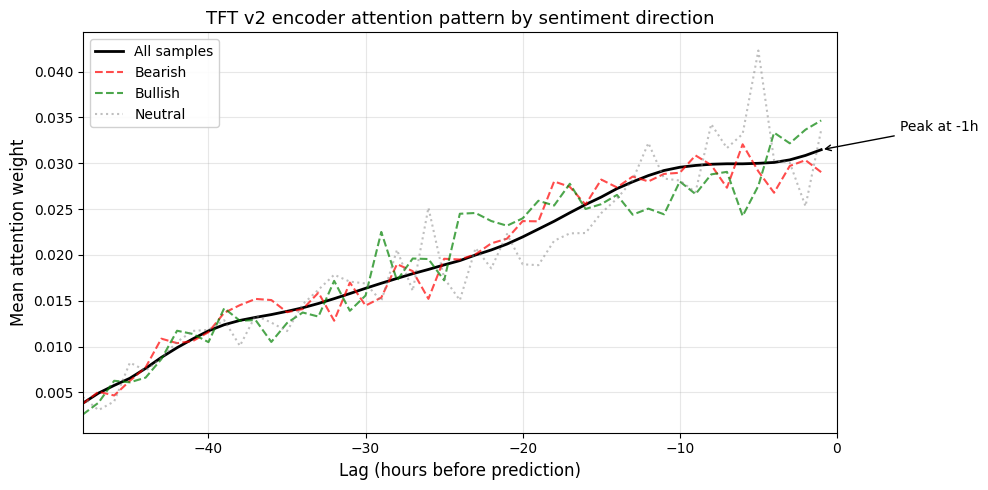

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load attention arrays
attn = np.load(VARIANT_OUT_DIR / 'attention.npz')
lag_labels = np.arange(-48, 0)  # -48h to -1h

fig, ax = plt.subplots(figsize=(10, 5))

# Overall mean attention
ax.plot(lag_labels, attn['mean_attention'],
        label='All samples', linewidth=2, color='black')

# Sentiment-disaggregated
ax.plot(lag_labels, attn['mean_attention_bearish'],
        label='Bearish', linestyle='--', color='red', alpha=0.7)
ax.plot(lag_labels, attn['mean_attention_bullish'],
        label='Bullish', linestyle='--', color='green', alpha=0.7)
ax.plot(lag_labels, attn['mean_attention_neutral'],
        label='Neutral', linestyle=':', color='gray', alpha=0.5)

# Peak annotation
peak_lag = lag_labels[attn['mean_attention'].argmax()]
peak_weight = attn['mean_attention'].max()
ax.annotate(f'Peak at {peak_lag}h',
            xy=(peak_lag, peak_weight),
            xytext=(peak_lag + 5, peak_weight + 0.002),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black', lw=1))

ax.set_xlabel('Lag (hours before prediction)', fontsize=12)
ax.set_ylabel('Mean attention weight', fontsize=12)
ax.set_title('TFT v2 encoder attention pattern by sentiment direction', fontsize=13)
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-48, 0)

plt.tight_layout()

# Save
output_path = VARIANT_OUT_DIR / 'attention_by_sentiment.png'
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.savefig(VARIANT_OUT_DIR / 'attention_by_sentiment.pdf', bbox_inches='tight')
print(f'Figure saved → {output_path}')
plt.show()

# Cel 15.1 Criterion 2 test

In [29]:
from scipy import stats

def get_sentiment(raw_out, df_source):
    if isinstance(raw_out.index, pd.DataFrame):
        time_idxs = raw_out.index['time_idx'].values
    else:
        time_idxs = np.asarray(raw_out.index['time_idx'])
    return df_source.iloc[time_idxs]['sentiment_score'].values

val_sent = get_sentiment(val_raw, df)
test_sent = get_sentiment(test_raw, df)

# Recompute prewar/war masks for test
test_idx = test_raw.index['time_idx'].values if isinstance(test_raw.index, dict) else test_raw.index['time_idx'].values
prewar_mask = test_idx <  WAR_ONSET_IDX
war_mask    = test_idx >= WAR_ONSET_IDX

print("Criterion 2: Bearish vs Bullish directional asymmetry on log_volume\n")
THRESH = 0.1

for h_idx, h_label in zip(EVAL_HORIZON_INDICES, EVAL_HORIZON_LABELS):
    print(f"--- Horizon {h_label}h ---")

    t_idx = cfg['targets'].index('log_volume')
    val_pred  = val_raw.output['prediction'][t_idx].cpu().numpy()[:, h_idx, 3]
    test_pred = test_raw.output['prediction'][t_idx].cpu().numpy()[:, h_idx, 3]

    for slice_name, pred, sent in [
        ('val',         val_pred,  val_sent),
        ('test_full',   test_pred, test_sent),
        ('test_prewar', test_pred[prewar_mask], test_sent[prewar_mask]),
        ('test_war',    test_pred[war_mask],    test_sent[war_mask]),
    ]:
        bear = sent < -THRESH
        bull = sent > THRESH
        pb, pu = pred[bear], pred[bull]
        if len(pb) < 5 or len(pu) < 5:
            print(f"  {slice_name}: insufficient samples")
            continue
        t, p = stats.ttest_ind(pb, pu, equal_var=False)
        sig = 'YES' if p < 0.05 else 'NO'
        print(f"  {slice_name}: bear={pb.mean():.3f}, bull={pu.mean():.3f}, "
              f"diff={pb.mean()-pu.mean():+.3f}, p={p:.4f}, sig: {sig}")
    print()

Criterion 2: Bearish vs Bullish directional asymmetry on log_volume

--- Horizon 1h ---
  val: bear=8.345, bull=8.281, diff=+0.064, p=0.5779, sig: NO
  test_full: bear=8.928, bull=8.857, diff=+0.071, p=0.3159, sig: NO
  test_prewar: bear=8.853, bull=8.783, diff=+0.070, p=0.5429, sig: NO
  test_war: bear=9.001, bull=8.901, diff=+0.100, p=0.2525, sig: NO

--- Horizon 3h ---
  val: bear=7.938, bull=8.131, diff=-0.193, p=0.2697, sig: NO
  test_full: bear=8.732, bull=8.596, diff=+0.136, p=0.2467, sig: NO
  test_prewar: bear=8.706, bull=8.365, diff=+0.341, p=0.0581, sig: NO
  test_war: bear=8.756, bull=8.729, diff=+0.027, p=0.8687, sig: NO

--- Horizon 6h ---
  val: bear=8.186, bull=8.369, diff=-0.183, p=0.2297, sig: NO
  test_full: bear=8.633, bull=8.529, diff=+0.104, p=0.4001, sig: NO
  test_prewar: bear=8.470, bull=8.380, diff=+0.089, p=0.6360, sig: NO
  test_war: bear=8.788, bull=8.615, diff=+0.174, p=0.2846, sig: NO

--- Horizon 12h ---
  val: bear=8.277, bull=8.371, diff=-0.094, p=0.56

## Cell 16 — Save all artifacts

In [30]:
import pickle

def to_serializable(raw_out):
    """Convert pytorch-forecasting Prediction object to a plain dict of tensors."""
    return {
        'output': {k: v.cpu() if hasattr(v, 'cpu') else v for k, v in raw_out.output.items()},
        'y': tuple(t.cpu() if hasattr(t, 'cpu') else t for t in raw_out.y) if isinstance(raw_out.y, tuple) else raw_out.y.cpu(),
        'x': {k: (v.cpu() if hasattr(v, 'cpu') else v) for k, v in raw_out.x.items()} if hasattr(raw_out, 'x') and raw_out.x is not None else None,
        'index': raw_out.index if hasattr(raw_out, 'index') else None,
    }

pred_path = VARIANT_OUT_DIR / 'predictions.pkl'
with open(pred_path, 'wb') as f:
    pickle.dump({
        'val':  to_serializable(val_raw),
        'test': to_serializable(test_raw),
    }, f)
print(f'Predictions saved → {pred_path}')

# Run metadata
import subprocess as _sp
try:
    _git_rev = _sp.check_output(['git', 'rev-parse', 'HEAD'],
                                cwd=str(PROJECT_ROOT)).decode().strip()
except Exception:
    _git_rev = 'unavailable'

meta = {
    'ablation_variant':      ABLATION_VARIANT,
    'best_checkpoint':       best_path,
    'best_val_loss':         best_val_loss,
    'best_epoch':            best_epoch,
    'targets':               cfg['targets'],
    'max_prediction_length': cfg['max_prediction_length'],
    'encoder_length':        ENCODER_LENGTH,
    'train_end':             TRAIN_END,
    'val_start':             VAL_START,
    'val_end':               VAL_END,
    'test_start':            TEST_START,
    'test_end':              TEST_END,
    'war_onset_idx':         WAR_ONSET_IDX,
    'war_onset_datetime':    WAR_ONSET_DATETIME,
    'hidden_size':           32,
    'attention_head_size':   4,
    'dropout':               0.1,
    'seed':                  42,
    'total_hours':           TOTAL_HOURS,
    'git_rev':               _git_rev,
}
meta_path = VARIANT_OUT_DIR / 'run_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata saved   → {meta_path}')

Predictions saved → /content/drive/MyDrive/thesis/TFTv2/tft_v2_outputs/v2.2/predictions.pkl
Metadata saved   → /content/drive/MyDrive/thesis/TFTv2/tft_v2_outputs/v2.2/run_metadata.json


## Cell 17 — Summary

In [32]:
top5 = list(importance_dict.items())[:5]

print('=' * 60)
print(f'  {ABLATION_VARIANT} RUN COMPLETE')
print('=' * 60)
print(f'  Best epoch       : {best_epoch}')
print(f'  Best val_loss    : {best_val_loss:.4f}')

# Test loss (full)
_test_full = df_metrics[(df_metrics['slice'] == 'test_full') &
                        (df_metrics['target'] == cfg['targets'][0]) &
                        (df_metrics['horizon_h'] == 1)]
if len(_test_full):
    print(f'  Test MAE (1h)    : {_test_full["mae"].values[0]:.5f}')

_test_pw = df_metrics[(df_metrics['slice'] == 'test_prewar') &
                      (df_metrics['target'] == cfg['targets'][0]) &
                      (df_metrics['horizon_h'] == 1)]
if len(_test_pw):
    print(f'  Test MAE pre-war : {_test_pw["mae"].values[0]:.5f}')

_test_w = df_metrics[(df_metrics['slice'] == 'test_war') &
                     (df_metrics['target'] == cfg['targets'][0]) &
                     (df_metrics['horizon_h'] == 1)]
if len(_test_w):
    print(f'  Test MAE war     : {_test_w["mae"].values[0]:.5f}')

print(f'  Peak attention lag: {peak_lag}h')
print(f'  Top 5 features:')
for name, val in top5:
    print(f'    {name:<35} {val:.4f}')
print('=' * 60)

  v2.2 RUN COMPLETE
  Best epoch       : 10
  Best val_loss    : 0.4270
  Test MAE (1h)    : 0.58542
  Test MAE pre-war : 0.53585
  Test MAE war     : 0.62772
  Peak attention lag: -1h
  Top 5 features:
    vix                                 0.1879
    supply_impact                       0.1210
    ent_oman                            0.1132
    demand_impact                       0.0547
    is_wednesday                        0.0222


# Cell 18: Criterion evaluation

In [33]:
from scipy import stats

def asymmetry_test_v22(raw_out, sentiment, target='log_volume', horizon_idx=0, label=''):
    """Per-target per-horizon directional asymmetry t-test."""
    t_idx = cfg['targets'].index(target)
    pred = raw_out.output['prediction'][t_idx].cpu().numpy()
    # pred shape: (N, horizons, quantiles)
    pred_med = pred[:, horizon_idx, 3]

    THRESH = 0.1
    bear = sentiment < -THRESH
    bull = sentiment > THRESH

    pb, pu = pred_med[bear], pred_med[bull]
    if len(pb) < 5 or len(pu) < 5:
        return None
    t, p = stats.ttest_ind(pb, pu, equal_var=False)
    return {
        'horizon': EVAL_HORIZON_LABELS[horizon_idx],
        'bear_mean': pb.mean(),
        'bull_mean': pu.mean(),
        'diff': pb.mean() - pu.mean(),
        't': t,
        'p': p
    }

# Get sentiment scores for val and test (recompute since we lost the variables)
def get_sentiment(raw_out, df_source):
    if isinstance(raw_out.index, pd.DataFrame):
        time_idxs = raw_out.index['time_idx'].values
    else:
        time_idxs = np.asarray(raw_out.index['time_idx'])
    return df_source.iloc[time_idxs]['sentiment_score'].values

val_sent = get_sentiment(val_raw, df)
test_sent = get_sentiment(test_raw, df)

print("Criterion 2: Bearish vs Bullish directional asymmetry on log_volume (v2.2)\n")
for i, (h_idx, h_label) in enumerate(zip(EVAL_HORIZON_INDICES, EVAL_HORIZON_LABELS)):
    print(f"--- Horizon {h_label}h (idx={h_idx}) ---")
    for slice_name, sent, raw in [('val', val_sent, val_raw), ('test', test_sent, test_raw)]:
        # Inline the test, replacing the function call
        t_idx = cfg['targets'].index('log_volume')
        pred = raw.output['prediction'][t_idx].cpu().numpy()
        pred_med = pred[:, h_idx, 3]

        THRESH = 0.1
        bear = sent < -THRESH
        bull = sent > THRESH

        pb, pu = pred_med[bear], pred_med[bull]
        if len(pb) < 5 or len(pu) < 5:
            print(f"  {slice_name}: insufficient samples")
            continue
        t, p = stats.ttest_ind(pb, pu, equal_var=False)
        sig = 'YES' if p < 0.05 else 'NO'
        print(f"  {slice_name}: bear={pb.mean():.3f}, bull={pu.mean():.3f}, "
              f"diff={pb.mean()-pu.mean():+.3f}, p={p:.4f}, sig: {sig}")
    print()

Criterion 2: Bearish vs Bullish directional asymmetry on log_volume (v2.2)

--- Horizon 1h (idx=0) ---
  val: bear=8.345, bull=8.281, diff=+0.064, p=0.5779, sig: NO
  test: bear=8.928, bull=8.857, diff=+0.071, p=0.3159, sig: NO

--- Horizon 3h (idx=2) ---
  val: bear=7.938, bull=8.131, diff=-0.193, p=0.2697, sig: NO
  test: bear=8.732, bull=8.596, diff=+0.136, p=0.2467, sig: NO

--- Horizon 6h (idx=5) ---
  val: bear=8.186, bull=8.369, diff=-0.183, p=0.2297, sig: NO
  test: bear=8.633, bull=8.529, diff=+0.104, p=0.4001, sig: NO

--- Horizon 12h (idx=11) ---
  val: bear=8.277, bull=8.371, diff=-0.094, p=0.5614, sig: NO
  test: bear=8.220, bull=8.464, diff=-0.244, p=0.0700, sig: NO

